# ¿Cuál es la mejor tarifa?

Trabajas como analista para el operador de telecomunicaciones Megaline. La empresa ofrece a sus clientes dos tarifas de prepago, Surf y Ultimate. El departamento comercial quiere saber cuál de las tarifas genera más ingresos para poder ajustar el presupuesto de publicidad.

Vas a realizar un análisis preliminar de las tarifas basado en una selección de clientes relativamente pequeña. Tendrás los datos de 500 clientes de Megaline: quiénes son los clientes, de dónde son, qué tarifa usan, así como la cantidad de llamadas que hicieron y los mensajes de texto que enviaron en 2018. Tu trabajo es analizar el comportamiento de los clientes y determinar qué tarifa de prepago genera más ingresos.

[Te proporcionamos algunos comentarios para orientarte mientras completas este proyecto. Pero debes asegurarte de eliminar todos los comentarios entre corchetes antes de entregar tu proyecto.]

[Antes de sumergirte en el análisis de datos, explica por tu propia cuenta el propósito del proyecto y las acciones que planeas realizar.]

[Ten en cuenta que estudiar, modificar y analizar datos es un proceso iterativo. Es normal volver a los pasos anteriores y corregirlos/ampliarlos para permitir nuevos pasos.]

## Inicialización

In [66]:
import pandas as pd


## Cargar datos

In [67]:
calls = pd.read_csv('/datasets/megaline_calls.csv') 
internet = pd.read_csv('/datasets/megaline_internet.csv')
messages = pd.read_csv('/datasets/megaline_messages.csv')
plans = pd.read_csv('/datasets/megaline_plans.csv')
users = pd.read_csv('/datasets/megaline_users.csv')


## Preparar los datos

[Los datos para este proyecto se dividen en varias tablas. Explora cada una para tener una comprensión inicial de los datos. Si es necesario, haz las correcciones requeridas en cada tabla.]

In [68]:
calls.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB


In [69]:
internet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB


In [70]:
messages.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [71]:
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 256.0+ bytes


In [72]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB


## Tarifas

In [73]:

print(f"Forma del DataFrame: {plans.shape}")
print(plans.dtypes)


Forma del DataFrame: (2, 8)
messages_included          int64
mb_per_month_included      int64
minutes_included           int64
usd_monthly_pay            int64
usd_per_gb                 int64
usd_per_message          float64
usd_per_minute           float64
plan_name                 object
dtype: object


In [74]:
print(plans.head())

   messages_included  mb_per_month_included  minutes_included  \
0                 50                  15360               500   
1               1000                  30720              3000   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute plan_name  
0               20          10             0.03            0.03      surf  
1               70           7             0.01            0.01  ultimate  


[Describe lo que ves y observas en la información general y en la muestra de datos impresa para el precio de datos anterior. ¿Hay algún problema (tipos de datos no adecuados, datos ausentes, etc.) que pudieran necesitar investigación y cambios adicionales? ¿Cómo se puede arreglar?]

In [ ]:
El DataFrame cuenta con 8 columnas y las 2 filas corresponden a la información sobre las tarifas que serian surf y ultimate, las fechas no estan en formato datatime

## Corregir datos

[Corrige los problemas obvios con los datos basándote en las observaciones iniciales.]

In [75]:
# Para la tabla plans no se requieren correcciones 
#Los tipos de datos son apropiados paara el análisis 
print("Tabla plans: No requiere correcciones")

Tabla plans: No requiere correcciones


## Enriquecer los datos

[Agrega factores adicionales a los datos si crees que pudieran ser útiles.]

In [76]:
# Convertir MB a GB para facilitar comparaciones 
plans['gb_per_month_included'] = plans['mb_per_month_included'] / 1024
print(plans)

   messages_included  mb_per_month_included  minutes_included  \
0                 50                  15360               500   
1               1000                  30720              3000   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute plan_name  \
0               20          10             0.03            0.03      surf   
1               70           7             0.01            0.01  ultimate   

   gb_per_month_included  
0                   15.0  
1                   30.0  


## Usuarios/as

In [77]:
# Imprime la información general/resumida sobre el DataFrame de usuarios
print(f"Forma del DataFrame: {users.shape}")
print(users.dtypes)


Forma del DataFrame: (500, 8)
user_id        int64
first_name    object
last_name     object
age            int64
city          object
reg_date      object
plan          object
churn_date    object
dtype: object


In [78]:
# Imprime una muestra de datos para usuarios

print(users.head())

   user_id first_name  last_name  age                                   city  \
0     1000   Anamaria      Bauer   45  Atlanta-Sandy Springs-Roswell, GA MSA   
1     1001     Mickey  Wilkerson   28        Seattle-Tacoma-Bellevue, WA MSA   
2     1002     Carlee    Hoffman   36   Las Vegas-Henderson-Paradise, NV MSA   
3     1003   Reynaldo    Jenkins   52                          Tulsa, OK MSA   
4     1004    Leonila   Thompson   40        Seattle-Tacoma-Bellevue, WA MSA   

     reg_date      plan churn_date  
0  2018-12-24  ultimate        NaN  
1  2018-08-13      surf        NaN  
2  2018-10-21      surf        NaN  
3  2018-01-28      surf        NaN  
4  2018-05-23      surf        NaN  


[Describe lo que ves y observas en la información general y en la muestra de datos impresa para el precio de datos anterior. ¿Hay algún problema (tipos de datos no adecuados, datos ausentes, etc.) que pudieran necesitar investigación y cambios adicionales? ¿Cómo se puede arreglar?]

In [ ]:
para la tabla de users, encontramos en la información que si hay mezcla de datos en mayusculas y minusculas, guiones intermedios para separar información, valores ausentes, y formatos de fechas 

### Corregir los datos

[Corrige los problemas obvios con los datos basándote en las observaciones iniciales.]

In [79]:
#Convertir fechas en la tabla users

users['reg_date'] = pd.to_datetime(users['reg_date'])
users['churn_date'] = pd.to_datetime(users['churn_date'])

# Convertir fechas en la tabla calls

calls['call_date'] = pd.to_datetime(calls['call_date'])

# Convertir fechas en la tabla messages

messages['message_date'] = pd.to_datetime(messages['message_date'])

# Convertir fechas en la tabla internet

internet['session_date'] = pd.to_datetime(internet['session_date'])

 

In [80]:
# Convertir nombres de planes a minúsculas para consistencia

users['plan'] = users['plan'].str.lower()

# Verificar que los planes coincidan con los de la tabla plans

print("Planes únicos en users:", users['plan'].unique())
print("Planes únicos en plans:", plans['plan_name'].unique())

Planes únicos en users: ['ultimate' 'surf']
Planes únicos en plans: ['surf' 'ultimate']


In [81]:
print("Tipos de datos en users:")
print(users[['reg_date', 'churn_date']].dtypes)
print("\nTipos de datos en calls:")
print(calls[['call_date']].dtypes)
print("\nTipos de datos en messages:")
print(messages[['message_date']].dtypes)
print("\nTipos de datos en internet:")
print(internet[['session_date']].dtypes)


Tipos de datos en users:
reg_date      datetime64[ns]
churn_date    datetime64[ns]
dtype: object

Tipos de datos en calls:
call_date    datetime64[ns]
dtype: object

Tipos de datos en messages:
message_date    datetime64[ns]
dtype: object

Tipos de datos en internet:
session_date    datetime64[ns]
dtype: object


In [82]:
# Verificar cuántos usuarios no tienen churn_date (usuarios activos)

active_users = users['churn_date'].isna().sum()
total_users = len(users)
print(f"Usuarios activos (sin churn_date): {active_users}")
print(f"Total de usuarios: {total_users}")
print(f"Porcentaje de usuarios activos: {active_users/total_users*100: .1f}%")


Usuarios activos (sin churn_date): 466
Total de usuarios: 500
Porcentaje de usuarios activos:  93.2%


In [83]:
# Verificar estadísticas básicas de duracion de llamadas 

print("Estadísticas de duración de llamadas:")
print(calls['duration'].describe())
print(f"\nValores negativos o cero: {(calls['duration'] <= 0).sum()}")

Estadísticas de duración de llamadas:
count    137735.000000
mean          6.745927
std           5.839241
min           0.000000
25%           1.290000
50%           5.980000
75%          10.690000
max          37.600000
Name: duration, dtype: float64

Valores negativos o cero: 26834


In [84]:
# Redondear duraciones según reglas de telecomunicaciones 

import numpy as np

# Redondear duraciones hacia arriba (ceiling) - regla común en telecomunicaciones
calls['duration'] = np.ceil(calls['duration'])
print("Duraciones redondeadas hacia arriba")
print(calls['duration'].head(10))

Duraciones redondeadas hacia arriba
0     9.0
1    14.0
2    15.0
3     6.0
4     5.0
5     3.0
6     6.0
7    15.0
8     6.0
9     5.0
Name: duration, dtype: float64


In [85]:
# Verificar datos faltantes en todas las tablas

print("Valores nulos por tabla:")
print("Calls:", calls.isnull().sum().sum())
print("Messages:", messages.isnull().sum().sum()) 
print("Internet:", internet.isnull().sum().sum())
print("Users (excluyendo churn_date):", users.drop('churn_date', axis=1).isnull().sum().sum())


Valores nulos por tabla:
Calls: 0
Messages: 0
Internet: 0
Users (excluyendo churn_date): 0


### Enriquecer los datos

[Agrega factores adicionales a los datos si crees que pudieran ser útiles.]

In [86]:
# Explorar las ciudades únicas
print("Ciudades únicas en los datos:")
print(users['city'].unique())
print(f"\nTotal de ciudades: {users['city'].nunique()}")


Ciudades únicas en los datos:
['Atlanta-Sandy Springs-Roswell, GA MSA' 'Seattle-Tacoma-Bellevue, WA MSA'
 'Las Vegas-Henderson-Paradise, NV MSA' 'Tulsa, OK MSA'
 'Dallas-Fort Worth-Arlington, TX MSA'
 'San Francisco-Oakland-Berkeley, CA MSA' 'Grand Rapids-Kentwood, MI MSA'
 'Orlando-Kissimmee-Sanford, FL MSA'
 'San Jose-Sunnyvale-Santa Clara, CA MSA' 'Cleveland-Elyria, OH MSA'
 'Chicago-Naperville-Elgin, IL-IN-WI MSA' 'Knoxville, TN MSA'
 'New York-Newark-Jersey City, NY-NJ-PA MSA' 'Pittsburgh, PA MSA'
 'Fresno, CA MSA' 'Washington-Arlington-Alexandria, DC-VA-MD-WV MSA'
 'Indianapolis-Carmel-Anderson, IN MSA' 'Jacksonville, FL MSA'
 'Los Angeles-Long Beach-Anaheim, CA MSA'
 'Omaha-Council Bluffs, NE-IA MSA'
 'Houston-The Woodlands-Sugar Land, TX MSA'
 'Philadelphia-Camden-Wilmington, PA-NJ-DE-MD MSA'
 'Tampa-St. Petersburg-Clearwater, FL MSA' 'Birmingham-Hoover, AL MSA'
 'Oklahoma City, OK MSA' 'Charlotte-Concord-Gastonia, NC-SC MSA'
 'Denver-Aurora-Lakewood, CO MSA'
 'Nashville-Davids

In [87]:
# Crear variable binaria para NY-NJ

users['is_ny_nj'] = users['city'].str.contains('NY|NJ', case=False, na=False)

# Verificar los resultados
print("Distribución de usuarios NY-NJ vs otras regiones:")
print(users['is_ny_nj'].value_counts())
print(f"\nPorcentaje de usuarios en NY-NJ: {users['is_ny_nj'].mean()*100:.1f}%")

# Ver algunos ejemplos de ciudades clasificadas como NY-NJ
print("\nEjemplos de ciudades clasificadas como NY-NJ:")
ny_nj_cities = users[users['is_ny_nj'] == True]['city'].unique()
print(ny_nj_cities[:5])  


Distribución de usuarios NY-NJ vs otras regiones:
False    392
True     108
Name: is_ny_nj, dtype: int64

Porcentaje de usuarios en NY-NJ: 21.6%

Ejemplos de ciudades clasificadas como NY-NJ:
['San Jose-Sunnyvale-Santa Clara, CA MSA'
 'New York-Newark-Jersey City, NY-NJ-PA MSA'
 'Philadelphia-Camden-Wilmington, PA-NJ-DE-MD MSA'
 'Buffalo-Cheektowaga, NY MSA' 'Albany-Schenectady-Troy, NY MSA']


In [88]:
# Ver todas las ciudades clasificadas como NY-NJ
print("Todas las ciudades clasificadas como NY-NJ:")
ny_nj_cities = users[users['is_ny_nj'] == True]['city'].unique()
for city in ny_nj_cities:
    print(f"- {city}")


Todas las ciudades clasificadas como NY-NJ:
- San Jose-Sunnyvale-Santa Clara, CA MSA
- New York-Newark-Jersey City, NY-NJ-PA MSA
- Philadelphia-Camden-Wilmington, PA-NJ-DE-MD MSA
- Buffalo-Cheektowaga, NY MSA
- Albany-Schenectady-Troy, NY MSA
- Rochester, NY MSA


In [89]:
# Crear una clasificación más específica para NY-NJ
# Buscar específicamente por códigos de estado al final del nombre
users['is_ny_nj_refined'] = users['city'].str.contains(r', NY | NY-| NJ-| NJ ', case=False, na=False)

# Verificar los resultados de la clasificación refinada
print("Distribución con clasificación refinada:")
print(users['is_ny_nj_refined'].value_counts())
print(f"\nPorcentaje de usuarios en NY-NJ (refinado): {users['is_ny_nj_refined'].mean()*100:.1f}%")

# Ver las ciudades clasificadas con el método refinado
print("\nCiudades clasificadas como NY-NJ (método refinado):")
ny_nj_refined = users[users['is_ny_nj_refined'] == True]['city'].unique()
for city in ny_nj_refined:
    print(f"- {city}")


Distribución con clasificación refinada:
False    414
True      86
Name: is_ny_nj_refined, dtype: int64

Porcentaje de usuarios en NY-NJ (refinado): 17.2%

Ciudades clasificadas como NY-NJ (método refinado):
- New York-Newark-Jersey City, NY-NJ-PA MSA
- Buffalo-Cheektowaga, NY MSA
- Albany-Schenectady-Troy, NY MSA
- Rochester, NY MSA


## Llamadas

In [90]:

print(f"Forma del DataFrame: {calls.shape}")
print(calls.dtypes)


Forma del DataFrame: (137735, 4)
id                   object
user_id               int64
call_date    datetime64[ns]
duration            float64
dtype: object


In [91]:
print(calls.head())


         id  user_id  call_date  duration
0   1000_93     1000 2018-12-27       9.0
1  1000_145     1000 2018-12-27      14.0
2  1000_247     1000 2018-12-27      15.0
3  1000_309     1000 2018-12-28       6.0
4  1000_380     1000 2018-12-30       5.0


[Describe lo que ves y observas en la información general y en la muestra de datos impresa para el precio de datos anterior. ¿Hay algún problema (tipos de datos no adecuados, datos ausentes, etc.) que pudieran necesitar investigación y cambios adicionales? ¿Cómo se puede arreglar?]

### Corregir los datos

[Corrige los problemas obvios con los datos basándote en las observaciones iniciales.]

### Enriquecer los datos

[Agrega factores adicionales a los datos si crees que pudieran ser útiles.]

## Mensajes

In [92]:
# Imprime la información general/resumida sobre el DataFrame de los mensajes
print(f"Forma del DataFrame: {messages.shape}")
print(messages.dtypes)


Forma del DataFrame: (76051, 3)
id                      object
user_id                  int64
message_date    datetime64[ns]
dtype: object


In [93]:
# Imprime una muestra de datos para los mensajes

print(messages.head(10))


         id  user_id message_date
0  1000_125     1000   2018-12-27
1  1000_160     1000   2018-12-31
2  1000_223     1000   2018-12-31
3  1000_251     1000   2018-12-27
4  1000_255     1000   2018-12-26
5  1000_346     1000   2018-12-29
6  1000_386     1000   2018-12-30
7  1000_413     1000   2018-12-31
8  1000_502     1000   2018-12-27
9  1000_525     1000   2018-12-28


[Describe lo que ves y observas en la información general y en la muestra de datos impresa para el precio de datos anterior. ¿Hay algún problema (tipos de datos no adecuados, datos ausentes, etc.) que pudieran necesitar investigación y cambios adicionales? ¿Cómo se puede arreglar?]

### Corregir los datos

[Corrige los problemas obvios con los datos basándote en las observaciones iniciales.]

### Enriquecer los datos

[Agrega factores adicionales a los datos si crees que pudieran ser útiles.]

## Internet

In [94]:
# Imprime la información general/resumida sobre el DataFrame de internet

print(f"Forma del DataFrame: {internet.shape}")
print(internet.dtypes)


Forma del DataFrame: (104825, 4)
id                      object
user_id                  int64
session_date    datetime64[ns]
mb_used                float64
dtype: object


In [95]:
# Imprime una muestra de datos para el tráfico de internet

print(internet.head(10))


         id  user_id session_date  mb_used
0   1000_13     1000   2018-12-29    89.86
1  1000_204     1000   2018-12-31     0.00
2  1000_379     1000   2018-12-28   660.40
3  1000_413     1000   2018-12-26   270.99
4  1000_442     1000   2018-12-27   880.22
5    1001_0     1001   2018-08-24   284.68
6    1001_3     1001   2018-12-09   656.04
7    1001_4     1001   2018-11-04    16.97
8   1001_10     1001   2018-11-27   135.18
9   1001_15     1001   2018-12-13   761.92


[Describe lo que ves y observas en la información general y en la muestra de datos impresa para el precio de datos anterior. ¿Hay algún problema (tipos de datos no adecuados, datos ausentes, etc.) que pudieran necesitar investigación y cambios adicionales? ¿Cómo se puede arreglar?]

### Corregir los datos

[Corrige los problemas obvios con los datos basándote en las observaciones iniciales.]

### Enriquecer los datos

[Agrega factores adicionales a los datos si crees que pudieran ser útiles.]

## Estudiar las condiciones de las tarifas

[Es sumamente importante entender cómo funcionan las tarifas, cómo se les cobra a los usuarios en función de su plan de suscripción. Así que te sugerimos imprimir la información de la tarifa para ver una vez más sus condiciones.]

In [96]:
# Imprime las condiciones de la tarifa y asegúrate de que te quedan claras

# Estudiar las condiciones de las tarifas
print("=== CONDICIONES DE LAS TARIFAS MEGALINE ===\n")

print("📱 TARIFA SURF:")
print("-" * 40)
print("• Pago mensual: $20")
print("• Incluye:")
print("  - 500 minutos al mes")
print("  - 50 SMS al mes") 
print("  - 15 GB de datos al mes")
print("• Si se exceden los límites:")
print("  - 1 minuto extra: 3 centavos ($0.03)")
print("  - 1 SMS extra: 3 centavos ($0.03)")
print("  - 1 GB extra: $10")
print()

print("🚀 TARIFA ULTIMATE:")
print("-" * 40)
print("• Pago mensual: $70")
print("• Incluye:")
print("  - 3000 minutos al mes")
print("  - 1000 SMS al mes")
print("  - 30 GB de datos al mes")
print("• Si se exceden los límites:")
print("  - 1 minuto extra: 1 centavo ($0.01)")
print("  - 1 SMS extra: 1 centavo ($0.01)")
print("  - 1 GB extra: $7")
print()

print("⚠️  REGLAS DE REDONDEO IMPORTANTES:")
print("-" * 40)
print("• LLAMADAS: Cada llamada se redondea hacia arriba")
print("  - Incluso 1 segundo = 1 minuto completo")
print("• DATOS: El total mensual se redondea hacia arriba")
print("  - Ejemplo: 1025 MB = 2 GB completos")
print("• SMS: No se redondean (se cuentan exactos)")


=== CONDICIONES DE LAS TARIFAS MEGALINE ===

📱 TARIFA SURF:
----------------------------------------
• Pago mensual: $20
• Incluye:
  - 500 minutos al mes
  - 50 SMS al mes
  - 15 GB de datos al mes
• Si se exceden los límites:
  - 1 minuto extra: 3 centavos ($0.03)
  - 1 SMS extra: 3 centavos ($0.03)
  - 1 GB extra: $10

🚀 TARIFA ULTIMATE:
----------------------------------------
• Pago mensual: $70
• Incluye:
  - 3000 minutos al mes
  - 1000 SMS al mes
  - 30 GB de datos al mes
• Si se exceden los límites:
  - 1 minuto extra: 1 centavo ($0.01)
  - 1 SMS extra: 1 centavo ($0.01)
  - 1 GB extra: $7

⚠️  REGLAS DE REDONDEO IMPORTANTES:
----------------------------------------
• LLAMADAS: Cada llamada se redondea hacia arriba
  - Incluso 1 segundo = 1 minuto completo
• DATOS: El total mensual se redondea hacia arriba
  - Ejemplo: 1025 MB = 2 GB completos
• SMS: No se redondean (se cuentan exactos)


## Agregar datos por usuario

[Ahora que los datos están limpios, agrega los datos por usuario y por periodo para que solo haya un registro por usuario y por periodo. Esto facilitará mucho el análisis posterior.]

In [97]:
# Calcula el número de llamadas hechas por cada usuario al mes. Guarda el resultado.

# Primero, extraer año y mes de la fecha de llamada
calls['year'] = calls['call_date'].dt.year
calls['month'] = calls['call_date'].dt.month

# Verificar que se crearon correctamente
print("Columnas en calls:")
print(calls.columns.tolist())
print("\nPrimeras filas con las nuevas columnas:")
print(calls[['call_date', 'year', 'month']].head())

# Calcular el número de llamadas hechas por cada usuario al mes
calls_per_user_month = calls.groupby(['user_id', 'year', 'month']).size().reset_index(name='calls_count')

# Verificar el resultado
print("Primeras 10 filas del resultado:")
print(calls_per_user_month.head(10))

# Verificar la forma del DataFrame resultante
print(f"Forma del DataFrame: {calls_per_user_month.shape}")

# Ver estadísticas básicas
print("\nEstadísticas del número de llamadas por usuario-mes:")
print(calls_per_user_month['calls_count'].describe())


Columnas en calls:
['id', 'user_id', 'call_date', 'duration', 'year', 'month']

Primeras filas con las nuevas columnas:
   call_date  year  month
0 2018-12-27  2018     12
1 2018-12-27  2018     12
2 2018-12-27  2018     12
3 2018-12-28  2018     12
4 2018-12-30  2018     12
Primeras 10 filas del resultado:
   user_id  year  month  calls_count
0     1000  2018     12           16
1     1001  2018      8           27
2     1001  2018      9           49
3     1001  2018     10           65
4     1001  2018     11           64
5     1001  2018     12           56
6     1002  2018     10           11
7     1002  2018     11           55
8     1002  2018     12           47
9     1003  2018     12          149
Forma del DataFrame: (2258, 4)

Estadísticas del número de llamadas por usuario-mes:
count    2258.000000
mean       60.998671
std        31.770869
min         1.000000
25%        39.000000
50%        60.000000
75%        80.000000
max       205.000000
Name: calls_count, dtype: float

In [98]:
# Calcula la cantidad de minutos usados por cada usuario al mes. Guarda el resultado.
minutes_per_user_month = calls.groupby(['user_id', 'year', 'month'])['duration'].sum().reset_index(name='minutes_used')

print(minutes_per_user_month)


      user_id  year  month  minutes_used
0        1000  2018     12         124.0
1        1001  2018      8         182.0
2        1001  2018      9         315.0
3        1001  2018     10         393.0
4        1001  2018     11         426.0
...       ...   ...    ...           ...
2253     1498  2018     12         339.0
2254     1499  2018      9         346.0
2255     1499  2018     10         385.0
2256     1499  2018     11         308.0
2257     1499  2018     12         496.0

[2258 rows x 4 columns]


In [99]:
# Calcula el número de mensajes enviados por cada usuario al mes. Guarda el resultado.

# Extraer año y mes de la fecha de mensaje
messages['year'] = messages['message_date'].dt.year
messages['month'] = messages['message_date'].dt.month

# Calcular el número de mensajes enviados por cada usuario al mes
messages_per_user_month = messages.groupby(['user_id', 'year', 'month']).size().reset_index(name='messages_count')

# Verificar el resultado
print("Primeras 10 filas del resultado:")
print(messages_per_user_month.head(10))
print(f"Forma del DataFrame: {messages_per_user_month.shape}")
print("\nEstadísticas del número de mensajes por usuario-mes:")
print(messages_per_user_month['messages_count'].describe())



Primeras 10 filas del resultado:
   user_id  year  month  messages_count
0     1000  2018     12              11
1     1001  2018      8              30
2     1001  2018      9              44
3     1001  2018     10              53
4     1001  2018     11              36
5     1001  2018     12              44
6     1002  2018     10              15
7     1002  2018     11              32
8     1002  2018     12              41
9     1003  2018     12              50
Forma del DataFrame: (1806, 4)

Estadísticas del número de mensajes por usuario-mes:
count    1806.000000
mean       42.110188
std        33.122931
min         1.000000
25%        17.000000
50%        34.000000
75%        59.000000
max       266.000000
Name: messages_count, dtype: float64


In [100]:
# Calcula el volumen del tráfico de Internet usado por cada usuario al mes. Guarda el resultado.

# Extraer año y mes de la fecha de sesión
internet['year'] = internet['session_date'].dt.year
internet['month'] = internet['session_date'].dt.month

# Calcular el volumen total de datos usado por cada usuario al mes
internet_per_user_month = internet.groupby(['user_id', 'year', 'month'])['mb_used'].sum().reset_index(name='mb_used_total')

import numpy as np

# Convertir MB a GB y redondear hacia arriba
internet_per_user_month['gb_used'] = np.ceil(internet_per_user_month['mb_used_total'] / 1024)

# Verificar el resultado
print("Primeras 10 filas del resultado:")
print(internet_per_user_month.head(10))
print(f"Forma del DataFrame: {internet_per_user_month.shape}")
print("\nEstadísticas del tráfico de Internet por usuario-mes:")
print(internet_per_user_month['gb_used'].describe())


Primeras 10 filas del resultado:
   user_id  year  month  mb_used_total  gb_used
0     1000  2018     12        1901.47      2.0
1     1001  2018      8        6919.15      7.0
2     1001  2018      9       13314.82     14.0
3     1001  2018     10       22330.49     22.0
4     1001  2018     11       18504.30     19.0
5     1001  2018     12       19369.18     19.0
6     1002  2018     10        6552.01      7.0
7     1002  2018     11       19345.08     19.0
8     1002  2018     12       14396.24     15.0
9     1003  2018     12       27044.14     27.0
Forma del DataFrame: (2277, 5)

Estadísticas del tráfico de Internet por usuario-mes:
count    2277.000000
mean       16.989021
std         7.693683
min         1.000000
25%        13.000000
50%        17.000000
75%        21.000000
max        70.000000
Name: gb_used, dtype: float64


[Junta los datos agregados en un DataFrame para que haya un registro que represente lo que consumió un usuario único en un mes determinado.]

In [101]:

# Fusiona los datos de llamadas, minutos, mensajes e Internet con base en user_id y month

# Partimos del DataFrame de llamadas como base (puede ser cualquier agregado por user_id-year-month)
user_monthly_data = calls_per_user_month.copy()

# Fusionar con minutos
user_monthly_data = user_monthly_data.merge(
    minutes_per_user_month,
    on=['user_id', 'year', 'month'],
    how='outer'
)

# Fusionar con mensajes
user_monthly_data = user_monthly_data.merge(
    messages_per_user_month,
    on=['user_id', 'year', 'month'],
    how='outer'
)

# Fusionar con internet
user_monthly_data = user_monthly_data.merge(
    internet_per_user_month,
    on=['user_id', 'year', 'month'],
    how='outer'
)

# Rellenar nulos con 0 para métricas numéricas
metric_cols = [col for col in user_monthly_data.columns if col not in ['user_id', 'year', 'month']]
user_monthly_data[metric_cols] = user_monthly_data[metric_cols].fillna(0)

print(user_monthly_data.head(10))


   user_id  year  month  calls_count  minutes_used  messages_count  \
0     1000  2018     12         16.0         124.0            11.0   
1     1001  2018      8         27.0         182.0            30.0   
2     1001  2018      9         49.0         315.0            44.0   
3     1001  2018     10         65.0         393.0            53.0   
4     1001  2018     11         64.0         426.0            36.0   
5     1001  2018     12         56.0         412.0            44.0   
6     1002  2018     10         11.0          59.0            15.0   
7     1002  2018     11         55.0         386.0            32.0   
8     1002  2018     12         47.0         384.0            41.0   
9     1003  2018     12        149.0        1104.0            50.0   

   mb_used_total  gb_used  
0        1901.47      2.0  
1        6919.15      7.0  
2       13314.82     14.0  
3       22330.49     22.0  
4       18504.30     19.0  
5       19369.18     19.0  
6        6552.01      7.0  
7    

In [102]:
# Añade la información de la tarifa


# Paso 1: Fusionar con la tabla users para obtener el plan de cada usuario
user_monthly_data = user_monthly_data.merge(
    users[['user_id', 'plan']], 
    on='user_id', 
    how='left'
)

# Paso 2: Fusionar con la tabla plans para obtener los detalles de cada tarifa
user_monthly_data = user_monthly_data.merge(
    plans, 
    left_on='plan', 
    right_on='plan_name', 
    how='left'
)

# Verificar el resultado
print("Columnas después de fusionar:")
print(user_monthly_data.columns.tolist())


Columnas después de fusionar:
['user_id', 'year', 'month', 'calls_count', 'minutes_used', 'messages_count', 'mb_used_total', 'gb_used', 'plan', 'messages_included', 'mb_per_month_included', 'minutes_included', 'usd_monthly_pay', 'usd_per_gb', 'usd_per_message', 'usd_per_minute', 'plan_name', 'gb_per_month_included']


[Calcula los ingresos mensuales por usuario (resta el límite del paquete gratuito del número total de llamadas, mensajes de texto y datos; multiplica el resultado por el valor del plan de llamadas; añade la tarifa mensual en función del plan de llamadas). Nota: Dadas las condiciones del plan, ¡esto podría no ser tan trivial como un par de líneas! Así que no pasa nada si dedicas algo de tiempo a ello.]

In [103]:
# Calcula el ingreso mensual para cada usuario


# Calcular excesos para cada servicio
user_monthly_data['exceso_minutos'] = (user_monthly_data['minutes_used'] - user_monthly_data['minutes_included']).clip(lower=0)
user_monthly_data['exceso_mensajes'] = (user_monthly_data['messages_count'] - user_monthly_data['messages_included']).clip(lower=0)
user_monthly_data['exceso_gb'] = (user_monthly_data['gb_used'] - user_monthly_data['gb_per_month_included']).clip(lower=0)

# Calcular cargos por excesos
user_monthly_data['cargo_exceso_minutos'] = user_monthly_data['exceso_minutos'] * user_monthly_data['usd_per_minute']
user_monthly_data['cargo_exceso_mensajes'] = user_monthly_data['exceso_mensajes'] * user_monthly_data['usd_per_message']
user_monthly_data['cargo_exceso_gb'] = user_monthly_data['exceso_gb'] * user_monthly_data['usd_per_gb']

# Calcular ingreso total mensual
user_monthly_data['ingreso_mensual'] = (
    user_monthly_data['usd_monthly_pay'] +  # Cuota base
    user_monthly_data['cargo_exceso_minutos'] +  # Exceso minutos
    user_monthly_data['cargo_exceso_mensajes'] +  # Exceso mensajes
    user_monthly_data['cargo_exceso_gb']  # Exceso datos
)

# Verificar las columnas del DataFrame
print("Columnas disponibles:")
print(user_monthly_data.columns.tolist())

# Verificar la forma del DataFrame
print(f"\nForma del DataFrame: {user_monthly_data.shape}")

# Ver las primeras filas para verificar que los cálculos se aplicaron
print("\nPrimeras 5 filas con los nuevos cálculos:")
print(user_monthly_data[['user_id', 'plan', 'minutes_used', 'exceso_minutos', 
                        'cargo_exceso_minutos', 'ingreso_mensual']].head())


Columnas disponibles:
['user_id', 'year', 'month', 'calls_count', 'minutes_used', 'messages_count', 'mb_used_total', 'gb_used', 'plan', 'messages_included', 'mb_per_month_included', 'minutes_included', 'usd_monthly_pay', 'usd_per_gb', 'usd_per_message', 'usd_per_minute', 'plan_name', 'gb_per_month_included', 'exceso_minutos', 'exceso_mensajes', 'exceso_gb', 'cargo_exceso_minutos', 'cargo_exceso_mensajes', 'cargo_exceso_gb', 'ingreso_mensual']

Forma del DataFrame: (2293, 25)

Primeras 5 filas con los nuevos cálculos:
   user_id      plan  minutes_used  exceso_minutos  cargo_exceso_minutos  \
0     1000  ultimate         124.0             0.0                   0.0   
1     1001      surf         182.0             0.0                   0.0   
2     1001      surf         315.0             0.0                   0.0   
3     1001      surf         393.0             0.0                   0.0   
4     1001      surf         426.0             0.0                   0.0   

   ingreso_mensual  

## Estudia el comportamiento de usuario

[Calcula algunas estadísticas descriptivas para los datos agregados y fusionados que nos sean útiles y que muestren un panorama general captado por los datos. Dibuja gráficos útiles para facilitar la comprensión. Dado que la tarea principal es comparar las tarifas y decidir cuál es más rentable, las estadísticas y gráficas deben calcularse por tarifa.]

[En los comentarios hallarás pistas relevantes para las llamadas, pero no las hay para los mensajes e Internet. Sin embargo, el principio del estudio estadístico que se aplica para ellos es el mismo que para las llamadas.]

### Llamadas

In [104]:
# Compara la duración promedio de llamadas por cada plan y por cada mes. Traza un gráfico de barras para visualizarla.

# Agregar información del plan a la tabla de llamadas
calls_with_plan = calls.merge(users[['user_id', 'plan']], on='user_id', how='left')

# Calcular la duración promedio por plan y mes
duracion_promedio = calls_with_plan.groupby(['plan', 'year', 'month'])['duration'].mean().reset_index()

# Crear una columna de fecha combinada para el eje X
duracion_promedio['fecha'] = duracion_promedio['year'].astype(str) + '-' + duracion_promedio['month'].astype(str).str.zfill(2)


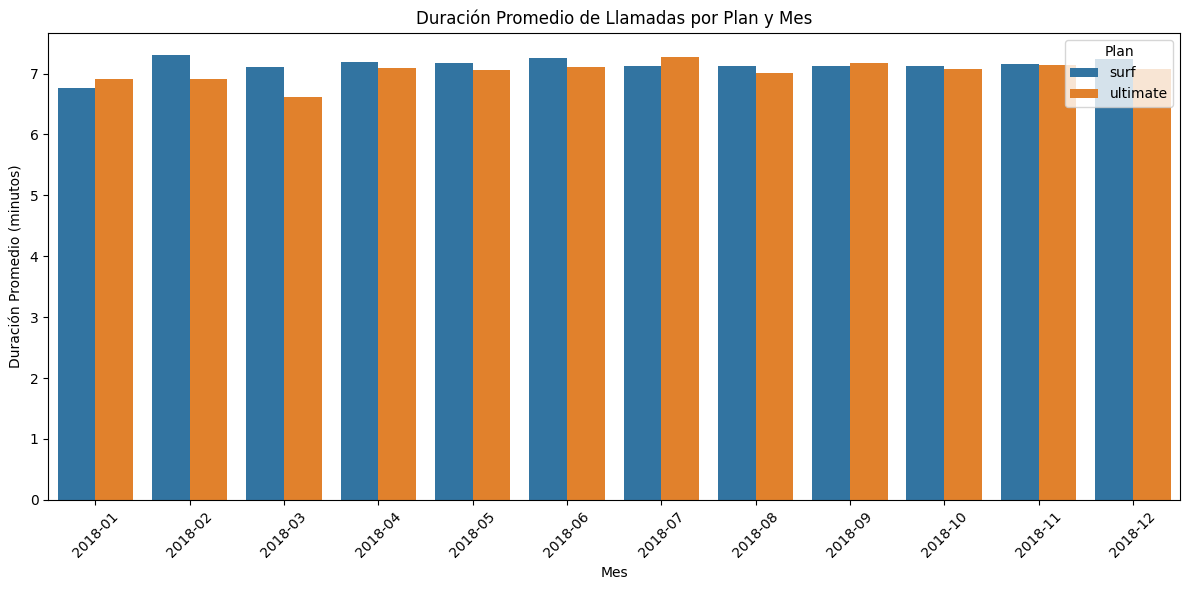

In [105]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar el estilo del gráfico
plt.figure(figsize=(12, 6))

# Crear el gráfico de barras agrupadas
sns.barplot(data=duracion_promedio, x='fecha', y='duration', hue='plan')

# Personalizar el gráfico
plt.title('Duración Promedio de Llamadas por Plan y Mes')
plt.xlabel('Mes')
plt.ylabel('Duración Promedio (minutos)')
plt.xticks(rotation=45)
plt.legend(title='Plan')
plt.tight_layout()
plt.show()

In [106]:
# Compara el número de minutos mensuales que necesitan los usuarios de cada plan. Traza un histograma.

# Verificar que tenemos los datos necesarios
print("Columnas disponibles:")
print(['minutes_used', 'plan'] if 'minutes_used' in user_monthly_data.columns else "Faltan columnas")

# Ver una muestra de los datos
print("\nPrimeras filas de minutos por plan:")
print(user_monthly_data[['user_id', 'plan', 'minutes_used']].head())


Columnas disponibles:
['minutes_used', 'plan']

Primeras filas de minutos por plan:
   user_id      plan  minutes_used
0     1000  ultimate         124.0
1     1001      surf         182.0
2     1001      surf         315.0
3     1001      surf         393.0
4     1001      surf         426.0


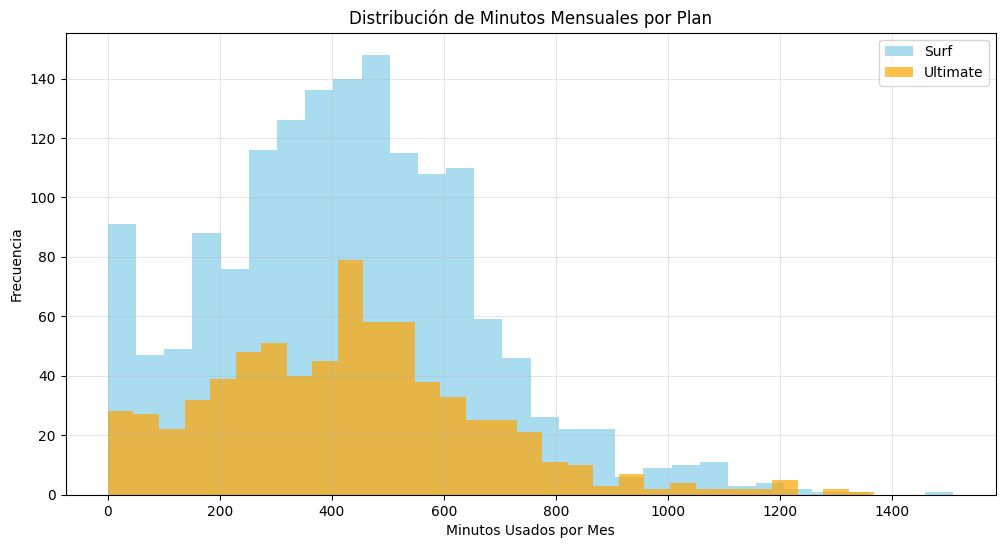

In [107]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar el estilo
plt.figure(figsize=(12, 6))

# Crear histogramas superpuestos para comparar
plt.hist(user_monthly_data[user_monthly_data['plan'] == 'surf']['minutes_used'], 
         bins=30, alpha=0.7, label='Surf', color='skyblue')
plt.hist(user_monthly_data[user_monthly_data['plan'] == 'ultimate']['minutes_used'], 
         bins=30, alpha=0.7, label='Ultimate', color='orange')

# Personalizar el gráfico
plt.title('Distribución de Minutos Mensuales por Plan')
plt.xlabel('Minutos Usados por Mes')
plt.ylabel('Frecuencia')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

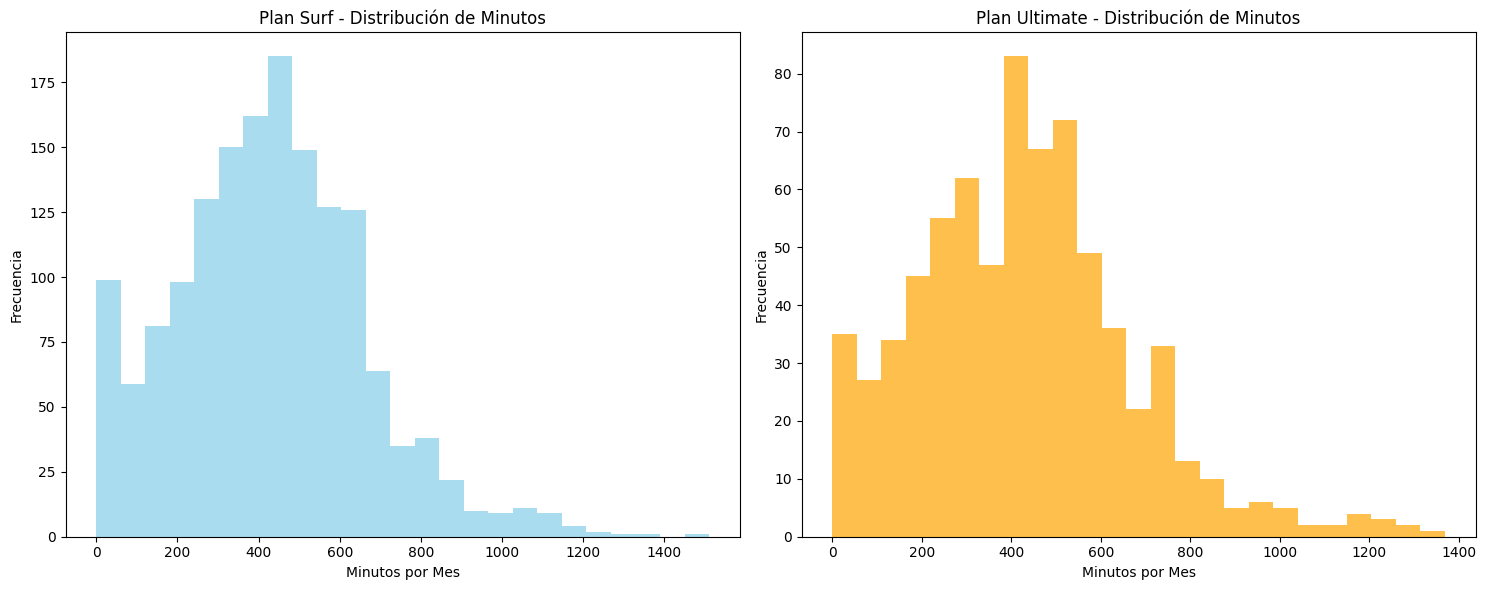

In [108]:
# Crear subgráficos para mejor comparación
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Histograma para Surf
axes[0].hist(user_monthly_data[user_monthly_data['plan'] == 'surf']['minutes_used'], 
             bins=25, color='skyblue', alpha=0.7)
axes[0].set_title('Plan Surf - Distribución de Minutos')
axes[0].set_xlabel('Minutos por Mes')
axes[0].set_ylabel('Frecuencia')

# Histograma para Ultimate
axes[1].hist(user_monthly_data[user_monthly_data['plan'] == 'ultimate']['minutes_used'], 
             bins=25, color='orange', alpha=0.7)
axes[1].set_title('Plan Ultimate - Distribución de Minutos')
axes[1].set_xlabel('Minutos por Mes')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

In [109]:
# Calcular estadísticas por plan
stats_by_plan = user_monthly_data.groupby('plan')['minutes_used'].describe()
print("Estadísticas de minutos mensuales por plan:")
print(stats_by_plan)

Estadísticas de minutos mensuales por plan:
           count        mean         std  min    25%    50%     75%     max
plan                                                                       
surf      1573.0  428.749523  234.453150  0.0  272.0  425.0  576.00  1510.0
ultimate   720.0  430.450000  240.508762  0.0  260.0  424.0  565.25  1369.0


[Calcula la media y la variable de la duración de las llamadas para averiguar si los usuarios de los distintos planes se comportan de forma diferente al realizar sus llamadas.]

In [110]:
# Calcula la media y la varianza de la duración mensual de llamadas.

# Verificar que tenemos los datos necesarios
print("Datos disponibles para el análisis:")
print(user_monthly_data[['user_id', 'plan', 'minutes_used']].head())

# Calcular estadísticas de duración mensual de llamadas por plan
print("=== MEDIA Y VARIANZA DE DURACIÓN MENSUAL DE LLAMADAS ===\n")

# Calcular media por plan
media_por_plan = user_monthly_data.groupby('plan')['minutes_used'].mean()
print("📊 MEDIA (minutos por mes):")
for plan, media in media_por_plan.items():
    print(f"  • {plan.capitalize()}: {media:.2f} minutos")

# Calcular varianza por plan
varianza_por_plan = user_monthly_data.groupby('plan')['minutes_used'].var()
print("\n📈 VARIANZA:")
for plan, varianza in varianza_por_plan.items():
    print(f"  • {plan.capitalize()}: {varianza:.2f}")

# Calcular desviación estándar para mejor interpretación
std_por_plan = user_monthly_data.groupby('plan')['minutes_used'].std()
print("\n📏 DESVIACIÓN ESTÁNDAR:")
for plan, std in std_por_plan.items():
    print(f"  • {plan.capitalize()}: {std:.2f} minutos")

# Crear un resumen estadístico completo
resumen_estadistico = user_monthly_data.groupby('plan')['minutes_used'].agg([
    'count', 'mean', 'var', 'std', 'min', 'max'
]).round(2)

print("\n📋 RESUMEN ESTADÍSTICO COMPLETO:")
print(resumen_estadistico)



Datos disponibles para el análisis:
   user_id      plan  minutes_used
0     1000  ultimate         124.0
1     1001      surf         182.0
2     1001      surf         315.0
3     1001      surf         393.0
4     1001      surf         426.0
=== MEDIA Y VARIANZA DE DURACIÓN MENSUAL DE LLAMADAS ===

📊 MEDIA (minutos por mes):
  • Surf: 428.75 minutos
  • Ultimate: 430.45 minutos

📈 VARIANZA:
  • Surf: 54968.28
  • Ultimate: 57844.46

📏 DESVIACIÓN ESTÁNDAR:
  • Surf: 234.45 minutos
  • Ultimate: 240.51 minutos

📋 RESUMEN ESTADÍSTICO COMPLETO:
          count    mean       var     std  min     max
plan                                                  
surf       1573  428.75  54968.28  234.45  0.0  1510.0
ultimate    720  430.45  57844.46  240.51  0.0  1369.0


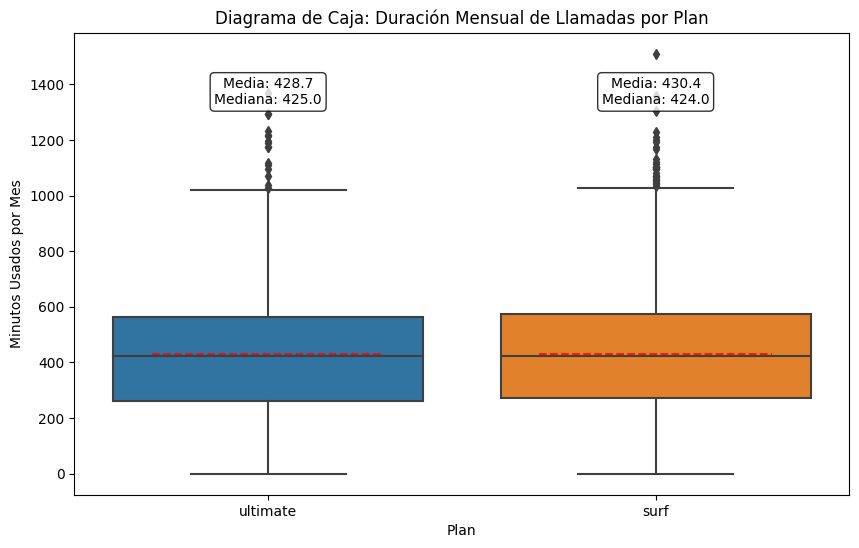

In [111]:
# Traza un diagrama de caja para visualizar la distribución de la duración mensual de llamadas

# Crear diagrama de caja con estadísticas
fig, ax = plt.subplots(figsize=(10, 6))

# Crear el boxplot usando seaborn para mejor control
sns.boxplot(data=user_monthly_data, x='plan', y='minutes_used', ax=ax)

# Agregar información estadística
for i, plan in enumerate(['surf', 'ultimate']):
    data = user_monthly_data[user_monthly_data['plan'] == plan]['minutes_used']
    median = data.median()
    mean = data.mean()
    
    # Agregar línea de la media
    ax.hlines(mean, i-0.3, i+0.3, colors='red', linestyles='dashed', alpha=0.8)
    
    # Agregar texto con estadísticas
    ax.text(i, ax.get_ylim()[1]*0.9, f'Media: {mean:.1f}\nMediana: {median:.1f}', 
            ha='center', va='top', fontsize=10, 
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.title('Diagrama de Caja: Duración Mensual de Llamadas por Plan')
plt.xlabel('Plan')
plt.ylabel('Minutos Usados por Mes')
plt.show()


[Elabora las conclusiones sobre el comportamiento de los usuarios con respecto a las llamadas. ¿Su comportamiento varía en función del plan?]

### Mensajes

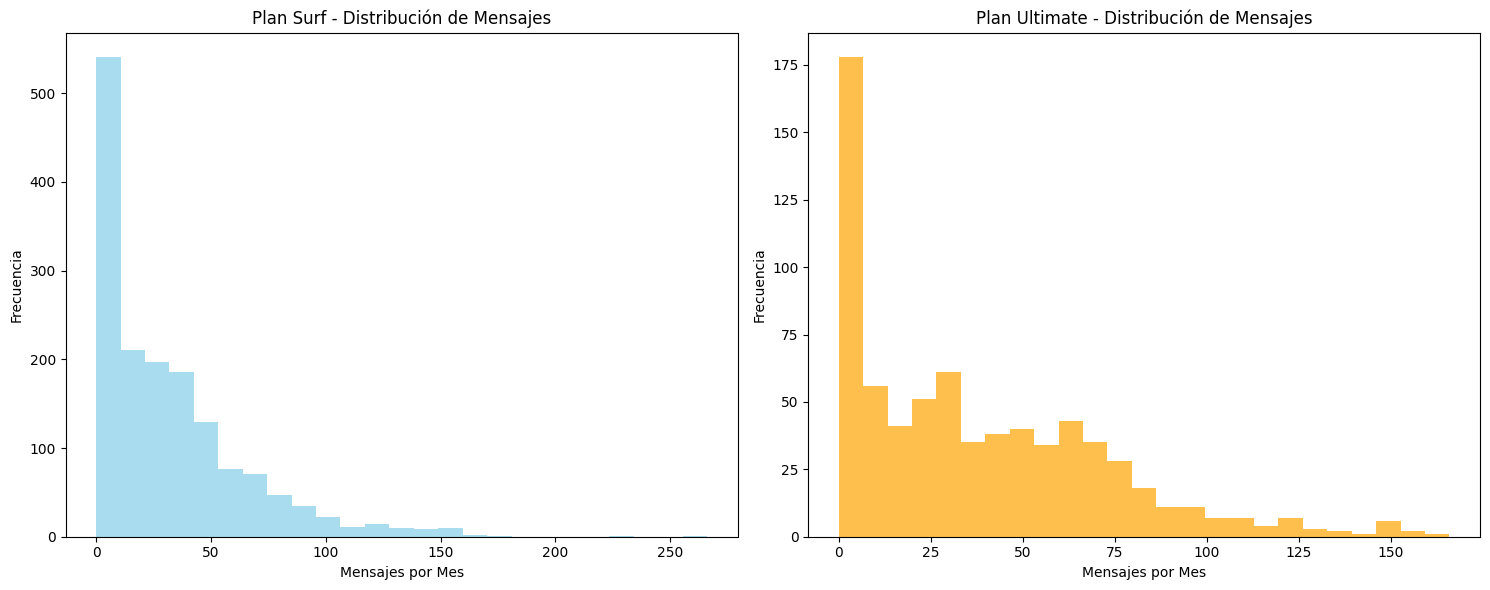

In [112]:
# Crear subgráficos para mejor comparación
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Histograma para Surf
axes[0].hist(user_monthly_data[user_monthly_data['plan'] == 'surf']['messages_count'], 
             bins=25, color='skyblue', alpha=0.7)
axes[0].set_title('Plan Surf - Distribución de Mensajes')
axes[0].set_xlabel('Mensajes por Mes')
axes[0].set_ylabel('Frecuencia')

# Histograma para Ultimate
axes[1].hist(user_monthly_data[user_monthly_data['plan'] == 'ultimate']['messages_count'], 
             bins=25, color='orange', alpha=0.7)
axes[1].set_title('Plan Ultimate - Distribución de Mensajes')
axes[1].set_xlabel('Mensajes por Mes')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

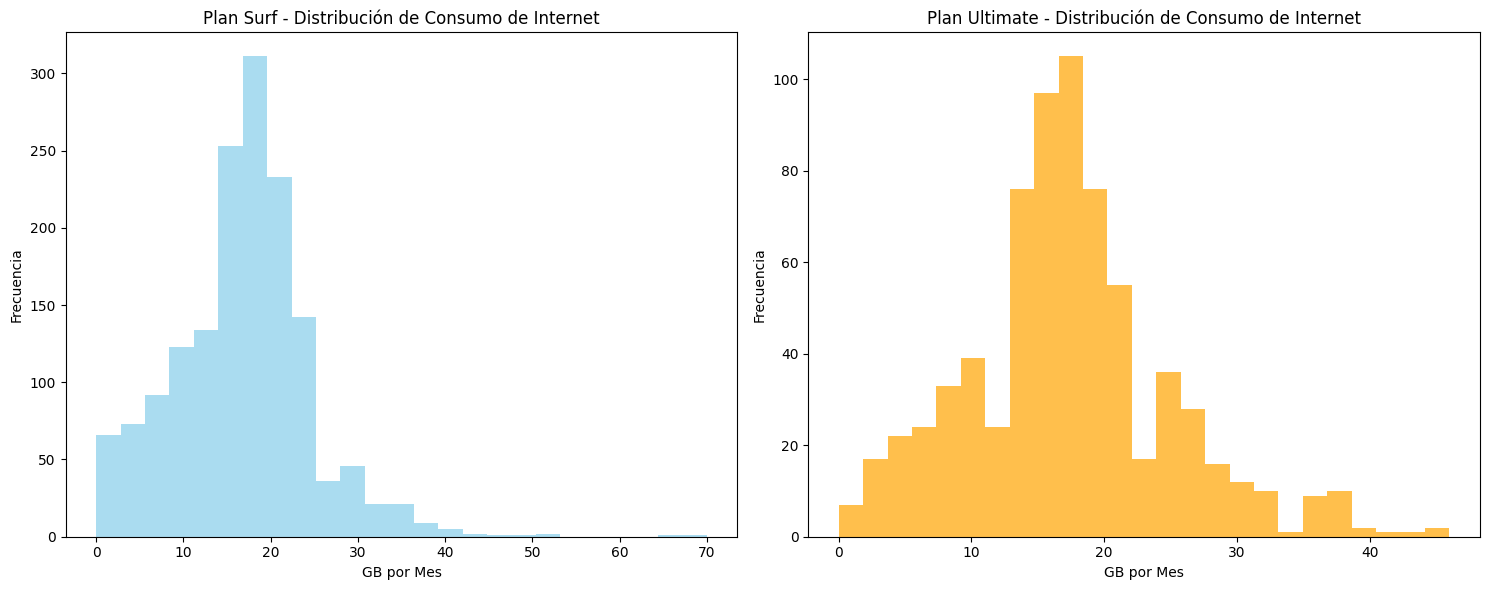

In [113]:
# Compara la cantidad de tráfico de Internet consumido por usuarios por plan

# Crear subgráficos para mejor comparación
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Histograma para Surf
axes[0].hist(user_monthly_data[user_monthly_data['plan'] == 'surf']['gb_used'],
             bins=25, color='skyblue', alpha=0.7)
axes[0].set_title('Plan Surf - Distribución de Consumo de Internet')
axes[0].set_xlabel('GB por Mes')
axes[0].set_ylabel('Frecuencia')

# Histograma para Ultimate
axes[1].hist(user_monthly_data[user_monthly_data['plan'] == 'ultimate']['gb_used'],
             bins=25, color='orange', alpha=0.7)
axes[1].set_title('Plan Ultimate - Distribución de Consumo de Internet')
axes[1].set_xlabel('GB por Mes')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()



[Elabora las conclusiones sobre el comportamiento de los usuarios con respecto a los mensajes. ¿Su comportamiento varía en función del plan?]

### Internet

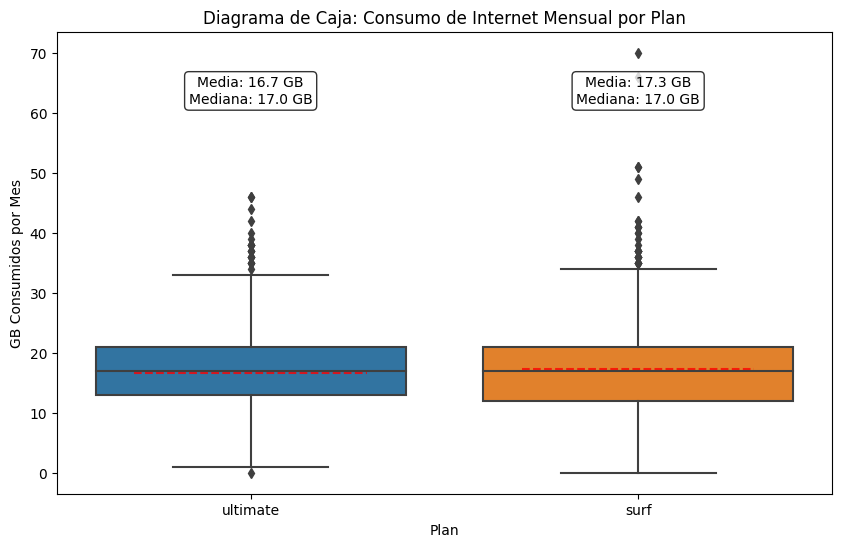

In [114]:
# Crear diagrama de caja para consumo de Internet
fig, ax = plt.subplots(figsize=(10, 6))

# Crear el boxplot
sns.boxplot(data=user_monthly_data, x='plan', y='gb_used', ax=ax)

# Agregar información estadística
for i, plan in enumerate(['surf', 'ultimate']):
    data = user_monthly_data[user_monthly_data['plan'] == plan]['gb_used']
    median = data.median()
    mean = data.mean()
    
    # Agregar línea de la media
    ax.hlines(mean, i-0.3, i+0.3, colors='red', linestyles='dashed', alpha=0.8)
    
    # Agregar texto con estadísticas
    ax.text(i, ax.get_ylim()[1]*0.9, f'Media: {mean:.1f} GB\nMediana: {median:.1f} GB', 
            ha='center', va='top', fontsize=10, 
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.title('Diagrama de Caja: Consumo de Internet Mensual por Plan')
plt.xlabel('Plan')
plt.ylabel('GB Consumidos por Mes')
plt.show()

[Elabora las conclusiones sobre cómo los usuarios tienden a consumir el tráfico de Internet. ¿Su comportamiento varía en función del plan?]

## Ingreso

[Del mismo modo que has estudiado el comportamiento de los usuarios, describe estadísticamente los ingresos de los planes.]

In [115]:
# Calcular estadísticas de ingresos por plan
stats_ingresos = user_monthly_data.groupby('plan')['ingreso_mensual'].describe()
print("Estadísticas de ingresos mensuales por plan:")
print(stats_ingresos)

Estadísticas de ingresos mensuales por plan:
           count       mean        std   min   25%    50%    75%     max
plan                                                                    
surf      1573.0  60.706408  55.388042  20.0  20.0  40.36  80.36  590.37
ultimate   720.0  72.313889  11.395108  70.0  70.0  70.00  70.00  182.00


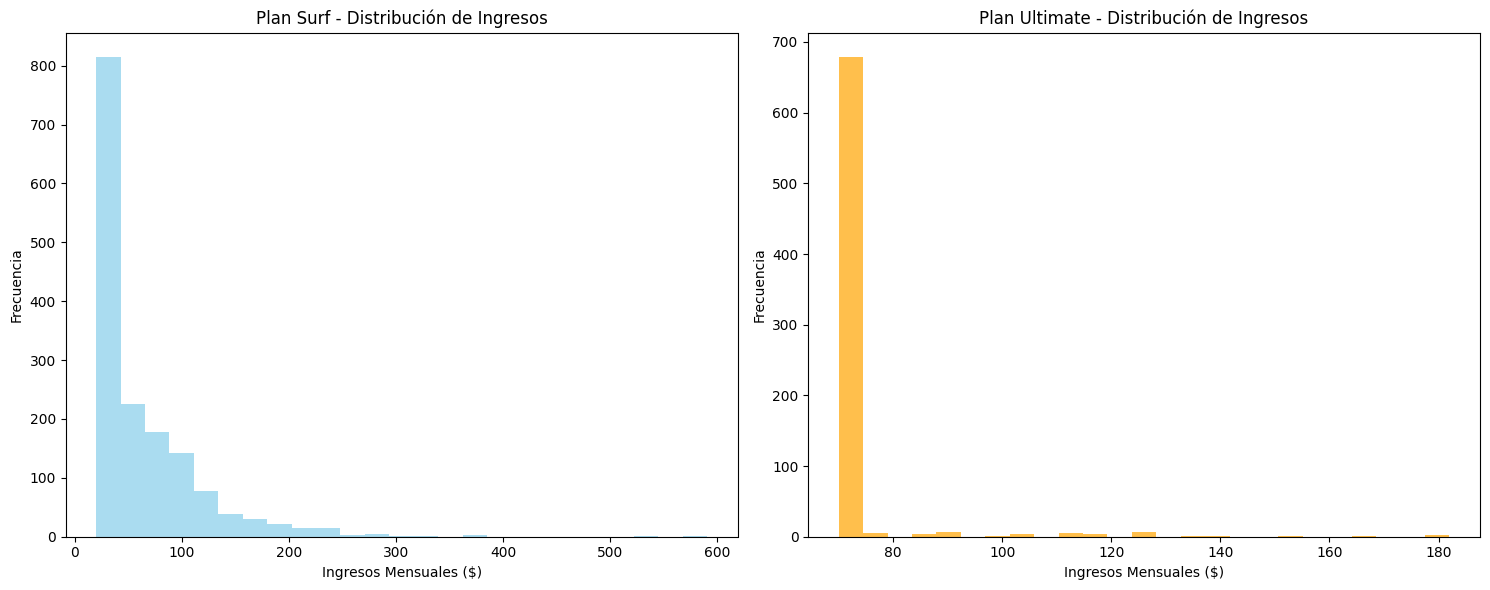

In [116]:
# Histogramas para comparar distribución de ingresos
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Histograma para Surf
axes[0].hist(user_monthly_data[user_monthly_data['plan'] == 'surf']['ingreso_mensual'],
             bins=25, color='skyblue', alpha=0.7)
axes[0].set_title('Plan Surf - Distribución de Ingresos')
axes[0].set_xlabel('Ingresos Mensuales ($)')
axes[0].set_ylabel('Frecuencia')

# Histograma para Ultimate
axes[1].hist(user_monthly_data[user_monthly_data['plan'] == 'ultimate']['ingreso_mensual'],
             bins=25, color='orange', alpha=0.7)
axes[1].set_title('Plan Ultimate - Distribución de Ingresos')
axes[1].set_xlabel('Ingresos Mensuales ($)')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

[Elabora las conclusiones sobre cómo difiere el ingreso entre los planes.]

## Prueba las hipótesis estadísticas

[Prueba la hipótesis de que son diferentes los ingresos promedio procedentes de los usuarios de los planes de llamada Ultimate y Surf.]

[Elabora las hipótesis nula y alternativa, escoge la prueba estadística, determina el valor alfa.]

In [117]:

# Prueba las hipótesis


# HIPÓTESIS 1: Comparar ingresos entre planes Ultimate y Surf
from scipy import stats as st
import numpy as np

print("=== PRUEBA DE HIPÓTESIS 1: INGRESOS POR PLAN ===")
print()

# Definir hipótesis
print("🎯 HIPÓTESIS:")
print("H₀: El ingreso promedio de Ultimate = El ingreso promedio de Surf")
print("H₁: El ingreso promedio de Ultimate ≠ El ingreso promedio de Surf")
print()

# Extraer datos de ingresos por plan
ingresos_surf = user_monthly_data[user_monthly_data['plan'] == 'surf']['ingreso_mensual']
ingresos_ultimate = user_monthly_data[user_monthly_data['plan'] == 'ultimate']['ingreso_mensual']

# Mostrar estadísticas básicas
print("📊 ESTADÍSTICAS BÁSICAS:")
print(f"Surf - Media: ${ingresos_surf.mean():.2f}, n = {len(ingresos_surf)}")
print(f"Ultimate - Media: ${ingresos_ultimate.mean():.2f}, n = {len(ingresos_ultimate)}")
print()

# Realizar la prueba t
alpha = 0.05
results = st.ttest_ind(ingresos_ultimate, ingresos_surf)

print("🔬 RESULTADOS DE LA PRUEBA:")
print(f"Estadístico t: {results.statistic:.4f}")
print(f"Valor p: {results.pvalue:.6f}")
print(f"Nivel de significancia (α): {alpha}")
print()

# Interpretar resultados
print("📋 CONCLUSIÓN:")
if results.pvalue < alpha:
    print("✅ Rechazamos la hipótesis nula")
    print("   Hay evidencia estadística de que los ingresos promedio son diferentes")
else:
    print("❌ No podemos rechazar la hipótesis nula")
    print("   No hay evidencia suficiente de diferencia en los ingresos promedio")


=== PRUEBA DE HIPÓTESIS 1: INGRESOS POR PLAN ===

🎯 HIPÓTESIS:
H₀: El ingreso promedio de Ultimate = El ingreso promedio de Surf
H₁: El ingreso promedio de Ultimate ≠ El ingreso promedio de Surf

📊 ESTADÍSTICAS BÁSICAS:
Surf - Media: $60.71, n = 1573
Ultimate - Media: $72.31, n = 720

🔬 RESULTADOS DE LA PRUEBA:
Estadístico t: 5.5689
Valor p: 0.000000
Nivel de significancia (α): 0.05

📋 CONCLUSIÓN:
✅ Rechazamos la hipótesis nula
   Hay evidencia estadística de que los ingresos promedio son diferentes


[Prueba la hipótesis de que el ingreso promedio de los usuarios del área NY-NJ es diferente al de los usuarios de otras regiones.]

[Elabora las hipótesis nula y alternativa, escoge la prueba estadística, determina el valor alfa.]

In [120]:
# Prueba las hipótesis
# HIPÓTESIS 2: Comparar ingresos entre NY-NJ y otras regiones
print("\n" + "="*60)
print("=== PRUEBA DE HIPÓTESIS 2: INGRESOS POR REGIÓN ===")
print()

# Definir hipótesis
print("🎯 HIPÓTESIS:")
print("H₀: El ingreso promedio en NY-NJ = El ingreso promedio en otras regiones")
print("H₁: El ingreso promedio en NY-NJ ≠ El ingreso promedio en otras regiones")
print()

# Extraer datos de ingresos por región (USANDO EL SUFIJO CORRECTO)
ingresos_ny_nj = user_monthly_data[user_monthly_data['is_ny_nj_refined_y'] == True]['ingreso_mensual']
ingresos_otras_regiones = user_monthly_data[user_monthly_data['is_ny_nj_refined_y'] == False]['ingreso_mensual']

# Mostrar estadísticas básicas
print("📊 ESTADÍSTICAS BÁSICAS:")
print(f"NY-NJ - Media: ${ingresos_ny_nj.mean():.2f}, n = {len(ingresos_ny_nj)}")
print(f"Otras regiones - Media: ${ingresos_otras_regiones.mean():.2f}, n = {len(ingresos_otras_regiones)}")
print()

# Realizar la prueba t
alpha = 0.05
results = st.ttest_ind(ingresos_ny_nj, ingresos_otras_regiones)

print("🔬 RESULTADOS DE LA PRUEBA:")
print(f"Estadístico t: {results.statistic:.4f}")
print(f"Valor p: {results.pvalue:.6f}")
print(f"Nivel de significancia (α): {alpha}")
print()

# Interpretar resultados
print("📋 CONCLUSIÓN:")
if results.pvalue < alpha:
    print("✅ Rechazamos la hipótesis nula")
    print("   Hay evidencia estadística de que los ingresos promedio son diferentes entre regiones")
else:
    print("❌ No podemos rechazar la hipótesis nula")
    print("   No hay evidencia suficiente de diferencia en los ingresos promedio entre regiones")


=== PRUEBA DE HIPÓTESIS 2: INGRESOS POR REGIÓN ===

🎯 HIPÓTESIS:
H₀: El ingreso promedio en NY-NJ = El ingreso promedio en otras regiones
H₁: El ingreso promedio en NY-NJ ≠ El ingreso promedio en otras regiones

📊 ESTADÍSTICAS BÁSICAS:
NY-NJ - Media: $60.90, n = 406
Otras regiones - Media: $65.09, n = 1887

🔬 RESULTADOS DE LA PRUEBA:
Estadístico t: -1.6423
Valor p: 0.100656
Nivel de significancia (α): 0.05

📋 CONCLUSIÓN:
❌ No podemos rechazar la hipótesis nula
   No hay evidencia suficiente de diferencia en los ingresos promedio entre regiones


## Conclusión general

[En esta sección final, enumera tus conclusiones importantes. Asegúrate de que estas abarquen todas las decisiones (suposiciones) importantes que adoptaste y que determinaron la forma elegida para procesar y analizar los datos.]

In [ ]:
1.- El numero de llamadas realizadas de manera mensual de los clientes se realizan de manera regular, de tal manera que los clientes son consientes de los minutos que tienen mensuales para usarlas.

2.- El plan más utilizado y preferible para los clientes es Surf que tiene un pago mensual de $20 pesos con 500 minutos al mes, 50 SMS y 15 GB de datos, esto quiere decir que es suficiente la cantidad de beneficios del plan que usan en su mayoría los clientes. 

3.- Aunque el plan Ultimate tiene mayores beneficios en su plan de manera mensual, los usuarios lo ocupan con menor frecuencia, sin aprovechar al máximo los beneficios, esto puede deberse a que no se tienen claros los limites del plan y se tendría que reforzar la información a manera de promoción o incentivar campañas que inviten a los usuarios a aprovechar los beneficios. 

4.- Para el consumo de internet se puede ver un uso con mayor frecuencia en el plan Ultimate, esto quiere decir que para que un usuario contrate un plan con mayores beneficios, depende de la cantidad de GB que use al mes, no toma en cuenta las llamadas ni mensajes. 

5.- Para la empresa los mayores ingresos que tiene es por el plan Surf, asi que es ideal considerar esta información para presupuestar gastos de la empresa. 

6.- De manera general se rechaza la hipótesis nula. 
